In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset.csv')
df.head()

,Date,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Result
0,1/1/1998,0.8,1.8,2.4,2.1,2,2.1,1.5,1.7,1.9,...,0.15,10.67,-1.56,5795,-12.1,17.9,10330,-55,0,0
1,1/2/1998,2.8,3.2,3.3,2.7,3.3,3.2,2.9,2.8,3.1,...,0.48,8.39,3.84,5805,14.05,29,10275,-55,0,0
2,1/3/1998,2.9,2.8,2.6,2.1,2.2,2.5,2.5,2.7,2.2,...,0.6,6.94,9.8,5790,17.9,41.3,10235,-40,0,0
3,1/4/1998,4.7,3.8,3.7,3.8,2.9,3.1,2.8,2.5,2.4,...,0.49,8.73,10.54,5775,31.15,51.7,10195,-40,2.08,0
4,1/5/1998,2.6,2.1,1.6,1.4,0.9,1.5,1.2,1.4,1.3,...,?,?,?,?,?,?,?,?,0.58,0


In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (2534, 74)
Columns: ['Date', 'WSR0', 'WSR1', 'WSR2', 'WSR3', 'WSR4', 'WSR5', 'WSR6', 'WSR7', 'WSR8', 'WSR9', 'WSR10', 'WSR11', 'WSR12', 'WSR13', 'WSR14', 'WSR15', 'WSR16', 'WSR17', 'WSR18', 'WSR19', 'WSR20', 'WSR21', 'WSR22', 'WSR23', 'WSR_PK', 'WSR_AV', 'T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19', 'T20', 'T21', 'T22', 'T23', 'T_PK', 'T_AV', 'T85', 'RH85', 'U85', 'V85', 'HT85', 'T70', 'RH70', 'U70', 'V70', 'HT70', 'T50', 'RH50', 'U50', 'V50', 'HT50', 'KI', 'TT', 'SLP', 'SLP_', 'Precp', 'Result']
       Date WSR0 WSR1 WSR2 WSR3 WSR4 WSR5 WSR6 WSR7 WSR8  ...  RH50    U50  \
0  1/1/1998  0.8  1.8  2.4  2.1    2  2.1  1.5  1.7  1.9  ...  0.15  10.67   
1  1/2/1998  2.8  3.2  3.3  2.7  3.3  3.2  2.9  2.8  3.1  ...  0.48   8.39   
2  1/3/1998  2.9  2.8  2.6  2.1  2.2  2.5  2.5  2.7  2.2  ...   0.6   6.94   
3  1/4/1998  4.7  3.8  3.7  3.8  2.9  3.1  2.8  2.5  2.4  ...  0.49   8.73   
4  1/5/1998  2.6 

In [4]:
df.describe()

,Result
count,2534.000000
mean,0.063141
std,0.243265
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [5]:
df.drop(columns='Date', inplace=True)
df.head()


,WSR0,WSR1,WSR2,WSR3,WSR4,WSR5,WSR6,WSR7,WSR8,WSR9,...,RH50,U50,V50,HT50,KI,TT,SLP,SLP_,Precp,Result
0,0.8,1.8,2.4,2.1,2,2.1,1.5,1.7,1.9,2.3,...,0.15,10.67,-1.56,5795,-12.1,17.9,10330,-55,0,0
1,2.8,3.2,3.3,2.7,3.3,3.2,2.9,2.8,3.1,3.4,...,0.48,8.39,3.84,5805,14.05,29,10275,-55,0,0
2,2.9,2.8,2.6,2.1,2.2,2.5,2.5,2.7,2.2,2.5,...,0.6,6.94,9.8,5790,17.9,41.3,10235,-40,0,0
3,4.7,3.8,3.7,3.8,2.9,3.1,2.8,2.5,2.4,3.1,...,0.49,8.73,10.54,5775,31.15,51.7,10195,-40,2.08,0
4,2.6,2.1,1.6,1.4,0.9,1.5,1.2,1.4,1.3,1.4,...,?,?,?,?,?,?,?,?,0.58,0


In [6]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

for col in df.columns:
    if col != 'Date':
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 WSR0      299
WSR1      292
WSR2      294
WSR3      292
WSR4      293
         ... 
TT        125
SLP        95
SLP_      158
Precp       2
Result      0
Length: 73, dtype: int64


In [8]:
df = df.fillna(df.mean(numeric_only=True))
print("Cleaned data shape:", df.shape)


Cleaned data shape: (2534, 73)


In [10]:
X = df.drop(columns=['Result'])
y = df['Result']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)


Features shape: (2534, 72)
Labels shape: (2534,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2027, 72)
Test shape: (507, 72)


In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [15]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Data Visualization

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
import seaborn as sns


C:\Users\adity\AppData\Local\Temp\ipykernel_7556\529859312.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['T_PK'], ax=ax1, shade=True, color='steelblue')


<Axes: xlabel='Temperature', ylabel='Frequency'>

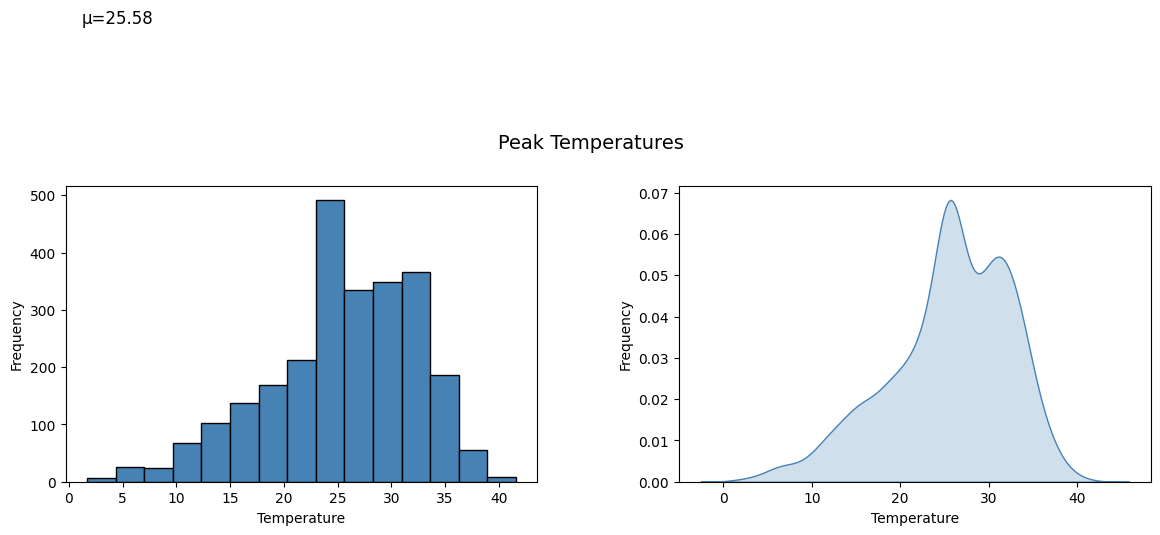

In [18]:
fig = plt.figure(figsize = (14,4))
title = fig.suptitle("Peak Temperatures", fontsize=14)
fig.subplots_adjust(top=0.85, wspace=0.3)

# Histogram
ax = fig.add_subplot(1,2, 1)
ax.set_xlabel("Temperature")
ax.set_ylabel("Frequency") 
ax.text(1.2, 800, r'μ='+str(round(df['T_PK'].mean(),2)), 
         fontsize=12)
freq, bins, patches = ax.hist(df['T_PK'], color='steelblue', bins=15,
                                    edgecolor='black', linewidth=1)


# Density Plot
ax1 = fig.add_subplot(1,2, 2)
ax1.set_xlabel("Temperature")
ax1.set_ylabel("Frequency") 
sns.kdeplot(df['T_PK'], ax=ax1, shade=True, color='steelblue')

C:\Users\adity\AppData\Local\Temp\ipykernel_7556\2125498499.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['T_PK'], ax=ax1, shade=True, color='steelblue')


<Axes: xlabel='Wind Speed', ylabel='Frequency'>

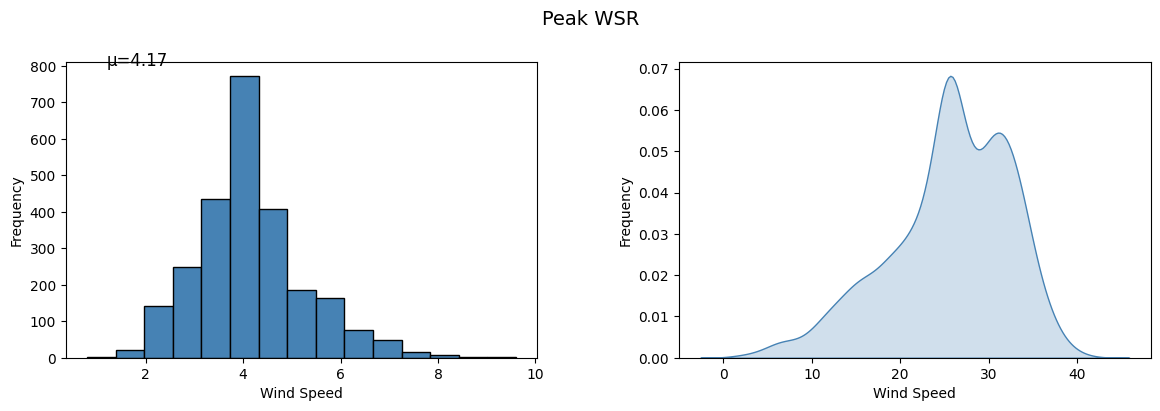

In [20]:
fig = plt.figure(figsize = (14,4))
title = fig.suptitle("Peak WSR", fontsize=14)
fig.subplots_adjust(top=0.85, wspace=0.3)

# Histogram
ax = fig.add_subplot(1,2, 1)
ax.set_xlabel("Wind Speed")
ax.set_ylabel("Frequency") 
ax.text(1.2, 800, r'μ='+str(round(df['WSR_PK'].mean(),2)), 
         fontsize=12)
freq, bins, patches = ax.hist(df['WSR_PK'], color='steelblue', bins=15,
                                    edgecolor='black', linewidth=1)


# Density Plot
ax1 = fig.add_subplot(1,2, 2)
ax1.set_xlabel("Wind Speed")
ax1.set_ylabel("Frequency") 
sns.kdeplot(df['T_PK'], ax=ax1, shade=True, color='steelblue')
     

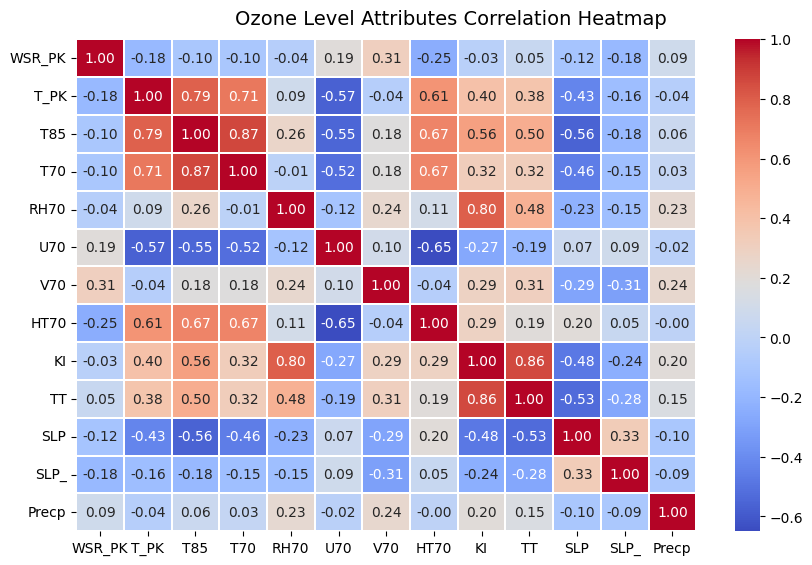

In [21]:

# Correlation Matrix Heatmap
f, ax = plt.subplots(figsize=(10, 6))
subset_attributes = ['WSR_PK','T_PK','T85','T70','RH70','U70','V70','HT70','KI','TT','SLP','SLP_','Precp']
corr = df[subset_attributes].corr()
hm = sns.heatmap(round(corr,2), annot=True, ax=ax, cmap="coolwarm",fmt='.2f',
                 linewidths=.05)
f.subplots_adjust(top=0.93)
t= f.suptitle('Ozone Level Attributes Correlation Heatmap', fontsize=14)

Model Training

Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)

In [23]:
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)


In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logreg_acc = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {logreg_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))


Logistic Regression Accuracy: 0.9546

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       475
           1       0.80      0.38      0.51        32

    accuracy                           0.95       507
   macro avg       0.88      0.68      0.74       507
weighted avg       0.95      0.95      0.95       507

Confusion Matrix:
 [[472   3]
 [ 20  12]]


SVM

In [33]:
from sklearn import svm

clf = svm.SVC(kernel='linear') 
clf.fit(X_train, y_train)

Y_pred = clf.predict(X_test)

In [34]:
from sklearn import metrics
print("\nClassification Report:\n", classification_report(y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, Y_pred))
print("Accuracy:", metrics.accuracy_score(y_test, Y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       475
           1       0.80      0.25      0.38        32

    accuracy                           0.95       507
   macro avg       0.88      0.62      0.68       507
weighted avg       0.94      0.95      0.94       507

Confusion Matrix:
 [[473   2]
 [ 24   8]]
Accuracy: 0.9487179487179487


KNN

In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

Y_pred = knn.predict(X_test)

In [36]:
print("\nClassification Report:\n", classification_report(y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, Y_pred))
print("Accuracy:",metrics.accuracy_score(y_test, Y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97       475
           1       0.25      0.03      0.06        32

    accuracy                           0.93       507
   macro avg       0.59      0.51      0.51       507
weighted avg       0.89      0.93      0.91       507

Confusion Matrix:
 [[472   3]
 [ 31   1]]
Accuracy: 0.9329388560157791


In [37]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [38]:
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

c:\Users\adity\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:27:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [39]:
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9527

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       475
           1       0.75      0.38      0.50        32

    accuracy                           0.95       507
   macro avg       0.85      0.68      0.74       507
weighted avg       0.95      0.95      0.95       507

Confusion Matrix:
 [[471   4]
 [ 20  12]]
